# SIT320 Pass Task: Graphs I & II - Code

Built on the lab notebook (Lab 6: Graphs II). The written reflection and discussion for each task is in the accompanying report.

***

In [1]:
# The following lines are used to increase the width of cells to utilize more space on the screen
# Note: the lab used 'from IPython.core.display import display, HTML' which was removed in IPython 8.
# The current import path is IPython.display.
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

***
### Section 0: Imports

In [2]:
import numpy as np
import math
import time
import random
from collections import deque

In [3]:
from IPython.display import Image
from graphviz import Digraph

***
### Section 1: Graph Preliminaries

Node and Graph classes from the lab. Two small fixes are flagged with comments: the lab's `Graph.__str__` was cut short (it never returned the string or printed the edges), and `reverseEdge` is kept as given.

In [4]:
class Node:

    def __init__(self, v):

        self.value = v
        self.inNeighbors = []
        self.outNeighbors = []

        #Adrian's suggestion:
        self.parent = None

        self.status = "unvisited"
        self.estD = np.inf

    def hasOutNeighbor(self, v):
        return v in self.outNeighbors

    def hasInNeighbor(self, v):
        return v in self.inNeighbors

    def hasNeighbor(self, v):
        return v in self.inNeighbors or v in self.outNeighbors

    def getOutNeighbors(self):
        return self.outNeighbors

    def getInNeighbors(self):
        return self.inNeighbors

    def getOutNeighborsWithWeights(self):
        return self.outNeighbors

    def getInNeighborsWithWeights(self):
        return self.inNeighbors

    # ------------------------------------------------
    # Modified to incorporate weights (as per the lab)
    # ------------------------------------------------

    def addOutNeighbor(self, v, wt):
        self.outNeighbors.append((v, wt))

    def addInNeighbor(self, v, wt):
        self.inNeighbors.append((v, wt))

    def __str__(self):
        return str(self.value)

In [5]:
class Graph:

    def __init__(self):
        self.vertices = []

    def addVertex(self, n):
        self.vertices.append(n)

    # ------------------------------------------------
    # Modified to incorporate weights (as per the lab)
    # ------------------------------------------------

    def addDiEdge(self, u, v, wt=1):
        u.addOutNeighbor(v, wt=wt)
        v.addInNeighbor(u, wt=wt)

    # add edges in both directions between u and v
    def addBiEdge(self, u, v, wt=1):
        self.addDiEdge(u, v, wt=wt)
        self.addDiEdge(v, u, wt=wt)

    # get a list of all the directed edges
    def getDirEdges(self):
        ret = []
        for v in self.vertices:
            ret += [[v, u] for u in v.outNeighbors]
        return ret

    # reverse the edge between u and v. Multiple edges are not supported.
    def reverseEdge(self, u, v):
        if u.hasOutNeighbor(v) and v.hasInNeighbor(u):
            if v.hasOutNeighbor(u) and u.hasInNeighbor(v):
                return
            self.addDiEdge(v, u)
            u.outNeighbors.remove(v)
            v.inNeighbors.remove(u)

    # Fix: the lab version built the vertex list but never returned it and never printed edges
    def __str__(self):
        ret = "Graph with:\n\t Vertices: "
        ret += ", ".join(str(v) for v in self.vertices)
        ret += "\n\t Edges: "
        ret += " ".join(f"({a} -> {b[0]}, wt {b[1]})" for a, b in self.getDirEdges())
        return ret

Two helpers on top of the lab code. `buildGraph` builds a graph from an edge list so each task does not repeat the `V[0], V[1]` wiring by hand. `drawGraph` replaces the lab's hand-typed `dot.edge('S', 'E')` cells: it renders the Digraph directly from the actual Graph object, so the picture always matches the data structure, weights included. Negative edges are drawn red, and an optional colour map fills the nodes (used for the colouring and bipartite tasks).

In [6]:
def buildGraph(names, edges, directed=True):
    """Build a Graph from a list of node names and (u, v, weight) tuples.
    Returns the graph and a name -> Node lookup dictionary."""
    G = Graph()
    lookup = {}
    for name in names:
        node = Node(name)
        lookup[name] = node
        G.addVertex(node)
    for u, v, wt in edges:
        if directed:
            G.addDiEdge(lookup[u], lookup[v], wt)
        else:
            G.addBiEdge(lookup[u], lookup[v], wt)
    return G, lookup

In [ ]:

PALETTE = ['#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3', '#fdb462']

def drawGraph(G, nodeColours=None, directed=True, showWeights=True,
              showDistances=False, showTree=False):
    """Render the Graph object with graphviz.
    nodeColours: optional {node: int} map to fill nodes (colouring / bipartite tasks).
    showDistances: annotate each node with its current estD, like the pink
                   distance boxes in the module notes.
    showTree: draw the shortest-path tree (each node's parent pointer) in bold blue."""

    dot = Digraph()
    dot.attr('node', style='filled', fillcolor='white')

    for node in G.vertices:
        fill = 'white'
        if nodeColours is not None:
            c = nodeColours.get(node)
            fill = PALETTE[c % len(PALETTE)] if c is not None else '#cccccc'
        label = str(node)
        if showDistances:
            d = node.estD
            dTxt = 'inf' if d == math.inf else f"{d:.0f}"
            label = f"{node}\nd = {dTxt}"
        dot.node(str(node), label=label, fillcolor=fill)

    seen = set()
    for u, (v, wt) in G.getDirEdges():
        if not directed:
            key = frozenset((str(u), str(v)))
            if key in seen:
                continue
            seen.add(key)
        onTree = showTree and v.parent == u
        colour = '#1f6fb2' if onTree else ('red' if wt < 0 else 'black')
        dot.edge(str(u), str(v), label=str(wt) if showWeights else '',
                 color=colour, fontcolor=colour,
                 penwidth='2.5' if onTree else '1',
                 dir='forward' if directed else 'none')

    return dot

The first example graph from the lab, built with the weights from the lab cells and drawn from the object:

Graph with:
	 Vertices: S, E, A, D, B, C
	 Edges: (S -> E, wt 8) (S -> A, wt 10) (E -> D, wt 1) (A -> C, wt 2) (D -> A, wt -4) (D -> C, wt -1) (B -> A, wt 1) (C -> B, wt -2)


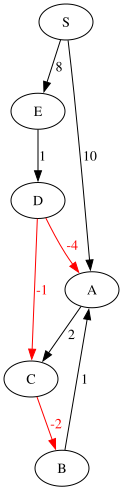

In [8]:
# Same graph the lab wires up by hand: S,E,A,D,B,C with three negative edges
labNames = ['S', 'E', 'A', 'D', 'B', 'C']
labEdges = [('S', 'E', 8), ('S', 'A', 10), ('E', 'D', 1), ('D', 'A', -4),
            ('A', 'C', 2), ('B', 'A', 1), ('D', 'C', -1), ('C', 'B', -2)]

G, L = buildGraph(labNames, labEdges)
print(G)
drawGraph(G)

***
### Section 2: Dijkstra Algorithm

The lab's Dijkstra with the parent initialisation fixed. The lab had `for i in len(G.vertices)` (Adrian's suggestion), which is not valid Python since you cannot iterate an int; the parents are now reset in the same loop that resets the distance estimates.

In [ ]:
def dijkstra(w, G):

    # Fix of Adrian's suggestion: reset parents in the same loop as the estimates
    for v in G.vertices:
        v.estD = math.inf
        v.parent = None

    w.estD = 0
    unsureVertices = G.vertices[:]
    sureVertices = []

    while len(unsureVertices) > 0:

        # find the u with the minimum estD 
        u = None
        minD = math.inf
        for x in unsureVertices:
            if x.estD < minD:
                minD = x.estD
                u = x

        if u is None:
            return

        # update u's neighbors
        for v, wt in u.getOutNeighborsWithWeights():
            if v in sureVertices:
                continue
            if u.estD + wt < v.estD:
                v.estD = u.estD + wt
                #Adrian's solution:
                v.parent = u

        unsureVertices.remove(u)
        sureVertices.append(u)


In [36]:
w = G.vertices[0]
dijkstra(w, G)

drawGraph(G, showDistances=True, showTree=True)

TypeError: drawGraph() got an unexpected keyword argument 'showDistances'

***
### Task 2: Graph Colouring Problem

In [11]:
def greedyColouring(G, maxColours=3):

    colours = {}

    for node in G.vertices:

        # note which colours the neighbours have already taken
        used = set()
        for neighbour, wt in node.getOutNeighborsWithWeights():
            if neighbour in colours and colours[neighbour] is not None:
                used.add(colours[neighbour])

        # assign the smallest colour not used by any neighbour
        assigned = None
        for c in range(maxColours):
            if c not in used:
                assigned = c
                break

        colours[node] = assigned

    return colours

In [12]:
def reportColouring(G, colours):
    for node in G.vertices:
        label = colours[node] if colours[node] is not None else "uncolourable"
        print(f"  {node}: {label}")

    # verify no two adjacent nodes share a colour
    valid = True
    for node in G.vertices:
        for neighbour, wt in node.getOutNeighborsWithWeights():
            if colours[node] is not None and colours[node] == colours[neighbour]:
                valid = False
    print(f"  Valid colouring (no adjacent nodes share a colour): {valid}")

Triangle with pendant node:
  A: 0
  B: 1
  C: 2
  D: 0
  Valid colouring (no adjacent nodes share a colour): True


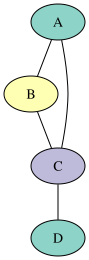

In [13]:
# Test 1: a triangle with a pendant node, 3-colourable
G1, L1 = buildGraph(['A', 'B', 'C', 'D'],
                    [('A', 'B', 1), ('B', 'C', 1), ('A', 'C', 1), ('C', 'D', 1)],
                    directed=False)
cols1 = greedyColouring(G1)
print("Triangle with pendant node:")
reportColouring(G1, cols1)
drawGraph(G1, nodeColours=cols1, directed=False, showWeights=False)

4-cycle:
  A: 0
  B: 1
  C: 0
  D: 1
  Valid colouring (no adjacent nodes share a colour): True


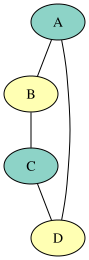

In [14]:
# Test 2: a 4-cycle, needs only 2 colours
G2, L2 = buildGraph(['A', 'B', 'C', 'D'],
                    [('A', 'B', 1), ('B', 'C', 1), ('C', 'D', 1), ('D', 'A', 1)],
                    directed=False)
cols2 = greedyColouring(G2)
print("4-cycle:")
reportColouring(G2, cols2)
drawGraph(G2, nodeColours=cols2, directed=False, showWeights=False)

Complete graph K4:
  A: 0
  B: 1
  C: 2
  D: uncolourable
  Valid colouring (no adjacent nodes share a colour): True


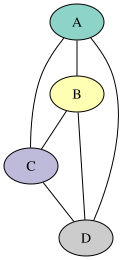

In [15]:
# Test 3: the complete graph K4, needs 4 colours so one node must fail (drawn grey)
G3, L3 = buildGraph(['A', 'B', 'C', 'D'],
                    [('A', 'B', 1), ('A', 'C', 1), ('A', 'D', 1),
                     ('B', 'C', 1), ('B', 'D', 1), ('C', 'D', 1)],
                    directed=False)
cols3 = greedyColouring(G3)
print("Complete graph K4:")
reportColouring(G3, cols3)
drawGraph(G3, nodeColours=cols3, directed=False, showWeights=False)

***
### Task 3: Test if Graph is Bipartite

In [16]:
def isBipartite(G):

    colour = {node: None for node in G.vertices}

    for start in G.vertices:

        if colour[start] is not None:
            continue

        # BFS from this component's start node
        colour[start] = 0
        queue = deque([start])

        while queue:
            u = queue.popleft()
            for v, wt in u.getOutNeighborsWithWeights():
                if colour[v] is None:
                    colour[v] = 1 - colour[u]
                    queue.append(v)
                elif colour[v] == colour[u]:
                    # two adjacent nodes with the same colour: odd cycle found
                    return False, None

    return True, colour

In [17]:
def reportBipartite(name, G, draw=False):
    ok, colouring = isBipartite(G)
    if ok:
        setA = [str(n) for n, c in colouring.items() if c == 0]
        setB = [str(n) for n, c in colouring.items() if c == 1]
        print(f"{name}: bipartite. Set A = {setA}, Set B = {setB}")
        if draw:
            return drawGraph(G, nodeColours=colouring, directed=False, showWeights=False)
    else:
        print(f"{name}: NOT bipartite (contains an odd cycle)")

4-cycle: bipartite. Set A = ['A', 'C'], Set B = ['B', 'D']


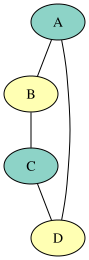

In [18]:
# Bipartite test case: 4-cycle, drawn with its two sets coloured
G4, _ = buildGraph(['A', 'B', 'C', 'D'],
                   [('A', 'B', 1), ('B', 'C', 1), ('C', 'D', 1), ('D', 'A', 1)],
                   directed=False)
reportBipartite("4-cycle", G4, draw=True)

Two-set graph: bipartite. Set A = ['U1', 'U2', 'U3'], Set B = ['W1', 'W2']


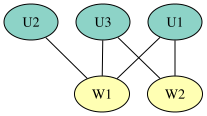

In [19]:
# Bipartite test case: an explicit two-set graph
G5, _ = buildGraph(['U1', 'U2', 'U3', 'W1', 'W2'],
                   [('U1', 'W1', 1), ('U1', 'W2', 1), ('U2', 'W1', 1),
                    ('U3', 'W1', 1), ('U3', 'W2', 1)],
                   directed=False)
reportBipartite("Two-set graph", G5, draw=True)

In [20]:
# Non-bipartite test cases: odd cycles
G6, _ = buildGraph(['A', 'B', 'C'],
                   [('A', 'B', 1), ('B', 'C', 1), ('C', 'A', 1)],
                   directed=False)
reportBipartite("Triangle (3-cycle)", G6)

G7, _ = buildGraph(['A', 'B', 'C', 'D', 'E'],
                   [('A', 'B', 1), ('B', 'C', 1), ('C', 'D', 1),
                    ('D', 'E', 1), ('E', 'A', 1)],
                   directed=False)
reportBipartite("5-cycle", G7)

Triangle (3-cycle): NOT bipartite (contains an odd cycle)
5-cycle: NOT bipartite (contains an odd cycle)


***
### Task 4: Bellman-Ford Algorithm (Activity 1 in the lab)

The lab's TODO skeleton looped node indices (`for u in range(0, len(G.vertices))`) and then called `u.getOutNeighborsWithWeights()` on the int, and its cycle check compared against a leftover `v_final`. This version keeps the lab's relaxation structure but iterates the actual Node objects, skips unreached nodes, and does the cycle check the standard way: one extra full pass after the n - 1 rounds.

In [21]:
def bellmanFord(w, G):
    """Single-source shortest paths from node w.
    Returns True if distances are valid, False if a negative cycle was detected."""

    for v in G.vertices:
        v.estD = math.inf
        v.parent = None
    w.estD = 0

    # relax every edge, n - 1 times
    for i in range(len(G.vertices) - 1):
        for u in G.vertices:
            if u.estD == math.inf:
                continue
            for v, wt in u.getOutNeighborsWithWeights():
                if u.estD + wt < v.estD:
                    v.estD = u.estD + wt
                    v.parent = u

    # one extra pass: any further improvement means a negative cycle
    for u in G.vertices:
        if u.estD == math.inf:
            continue
        for v, wt in u.getOutNeighborsWithWeights():
            if u.estD + wt < v.estD:
                return False

    return True

In [22]:
def getPath(source, target):
    """Walk the parent pointers back from target to source
    (same walk as the lab's path cell, wrapped as a function)."""
    if target.estD == math.inf:
        return None
    path = []
    current = target
    while current is not None and current != source:
        path.append(current)
        current = current.parent
    path.append(source)
    path.reverse()
    return path

In [23]:
# Test case 1: negative edge weights but no negative cycle (the lab example graph)
G8, L8 = buildGraph(labNames, labEdges)
ok = bellmanFord(L8['S'], G8)

print(f"Negative cycle detected: {not ok}\n")
print("Shortest paths from S:")
for v in G8.vertices:
    path = getPath(L8['S'], v)
    pathStr = " - ".join(str(x) for x in path) if path else "unreachable"
    print(f"  S to {v}: cost {v.estD}, path: {pathStr}")

Negative cycle detected: False

Shortest paths from S:
  S to S: cost 0, path: S
  S to E: cost 8, path: S - E
  S to A: cost 5, path: S - E - D - A
  S to D: cost 9, path: S - E - D
  S to B: cost 5, path: S - E - D - A - C - B
  S to C: cost 7, path: S - E - D - A - C


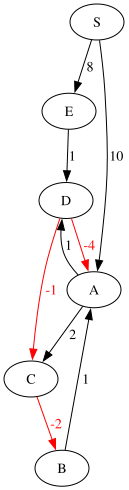

Negative cycle detected: shortest paths are not defined for this graph.


In [24]:
# Test case 2: a graph containing a negative-weight cycle.
# Adding A -> D (weight 1) creates the cycle A -> D -> A with total 1 + (-4) = -3.
edgesWithCycle = labEdges + [('A', 'D', 1)]

G9, L9 = buildGraph(labNames, edgesWithCycle)
display(drawGraph(G9))

ok = bellmanFord(L9['S'], G9)
if not ok:
    print("Negative cycle detected: shortest paths are not defined for this graph.")
else:
    print("No negative cycle found.")

***
### Task 5: Floyd-Warshall Algorithm (Activity 2 in the lab)

This follows the four parts sketched in the lab's TODO cell: Part 1 initialises the distance matrix (the skeleton's `np.zeros(n, n)` and `np.fill` calls were not real numpy API, `np.full((n, n), np.inf)` does the job), Part 2 is the DP triple loop, Part 3 detects negative cycles from the diagonal, and Part 4 prints paths. The skeleton's parents matrix is replaced with a next-hop matrix, which makes Part 4 a simple walk.

In [25]:
def floydWarshall(G):
    """All-pairs shortest paths.
    Returns (distance matrix, next-hop matrix, negative cycle flag)."""

    n = len(G.vertices)
    index = {node: i for i, node in enumerate(G.vertices)}

    # Part 1: initialise the distance and next-hop matrices
    distance = np.full((n, n), np.inf)
    np.fill_diagonal(distance, 0)
    nxt = [[None for _ in range(n)] for _ in range(n)]

    for u in G.vertices:
        i = index[u]
        for v, wt in u.getOutNeighborsWithWeights():
            j = index[v]
            if wt < distance[i, j]:
                distance[i, j] = wt
                nxt[i][j] = j
    for i in range(n):
        nxt[i][i] = i

    # Part 2: the DP triple loop
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if distance[i, k] + distance[k, j] < distance[i, j]:
                    distance[i, j] = distance[i, k] + distance[k, j]
                    nxt[i][j] = nxt[i][k]

    # Part 3: negative cycle check via the diagonal
    hasNegativeCycle = any(distance[i, i] < 0 for i in range(n))

    return distance, nxt, hasNegativeCycle

In [26]:
def reconstructPath(G, nxt, u, v):
    """Part 4: rebuild the shortest path from u to v using the next-hop matrix."""
    index = {node: i for i, node in enumerate(G.vertices)}
    i, j = index[u], index[v]
    if nxt[i][j] is None:
        return None
    path = [G.vertices[i]]
    while i != j:
        i = nxt[i][j]
        path.append(G.vertices[i])
    return path

In [27]:
def printDistanceMatrix(G, distance):
    names = [str(v) for v in G.vertices]
    header = "      " + "".join(f"{name:>7}" for name in names)
    print(header)
    for i, name in enumerate(names):
        row = f"{name:>6}"
        for j in range(len(names)):
            val = distance[i, j]
            row += f"{'inf':>7}" if val == np.inf else f"{val:>7.0f}"
        print(row)

In [28]:
# Test on the lab graph (negative weights, no negative cycle)
G10, L10 = buildGraph(labNames, labEdges)
distance, nxt, neg = floydWarshall(G10)

print(f"Negative cycle detected: {neg}\n")
print("Final distance matrix:")
printDistanceMatrix(G10, distance)

Negative cycle detected: False

Final distance matrix:
            S      E      A      D      B      C
     S      0      8      5      9      5      7
     E    inf      0     -3      1     -3     -1
     A    inf    inf      0    inf      0      2
     D    inf    inf     -4      0     -4     -2
     B    inf    inf      1    inf      0      3
     C    inf    inf     -1    inf     -2      0


In [29]:
# Extra credit: reconstruct and print the shortest path for every reachable pair
print("Shortest paths between all pairs:")
for u in G10.vertices:
    for v in G10.vertices:
        if u == v:
            continue
        i, j = G10.vertices.index(u), G10.vertices.index(v)
        if distance[i, j] == np.inf:
            continue
        path = reconstructPath(G10, nxt, u, v)
        pathStr = " - ".join(str(x) for x in path)
        print(f"  {u} to {v}: cost {distance[i, j]:.0f}, path: {pathStr}")

Shortest paths between all pairs:
  S to E: cost 8, path: S - E
  S to A: cost 5, path: S - E - D - A
  S to D: cost 9, path: S - E - D
  S to B: cost 5, path: S - E - D - A - C - B
  S to C: cost 7, path: S - E - D - A - C
  E to A: cost -3, path: E - D - A
  E to D: cost 1, path: E - D
  E to B: cost -3, path: E - D - A - C - B
  E to C: cost -1, path: E - D - A - C
  A to B: cost 0, path: A - C - B
  A to C: cost 2, path: A - C
  D to A: cost -4, path: D - A
  D to B: cost -4, path: D - A - C - B
  D to C: cost -2, path: D - A - C
  B to A: cost 1, path: B - A
  B to C: cost 3, path: B - A - C
  C to A: cost -1, path: C - B - A
  C to B: cost -2, path: C - B


In [30]:
# Test with a negative cycle present
G11, L11 = buildGraph(labNames, edgesWithCycle)
distance2, nxt2, neg2 = floydWarshall(G11)

if neg2:
    print("Negative cycle detected: the diagonal of the distance matrix contains negative values.")
    diag = [f"{v}: {distance2[i, i]:.0f}" for i, v in enumerate(G11.vertices) if distance2[i, i] < 0]
    print("Nodes on or reaching a negative cycle:", ", ".join(diag))

Negative cycle detected: the diagonal of the distance matrix contains negative values.
Nodes on or reaching a negative cycle: A: -11, D: -14, B: -14, C: -28


***
### Task 6: Johnson's Algorithm

In [31]:
def johnson(G):
    """All-pairs shortest paths via reweighting.
    Returns (distance matrix, negative cycle flag)."""

    # Step 1: add a virtual source q with zero-weight edges to every node
    q = Node('__q__')
    for v in G.vertices:
        q.addOutNeighbor(v, 0)
        v.addInNeighbor(q, 0)
    G.vertices.append(q)

    # Step 2: Bellman-Ford from q gives the potential h(v) for each node
    ok = bellmanFord(q, G)
    h = {v: v.estD for v in G.vertices}

    # remove q so the graph is back to its original shape
    G.vertices.remove(q)
    for v in G.vertices:
        v.inNeighbors = [(u, wt) for (u, wt) in v.inNeighbors if u != q]

    if not ok:
        return None, True

    n = len(G.vertices)
    index = {node: i for i, node in enumerate(G.vertices)}
    distance = np.full((n, n), np.inf)

    # Step 3: reweight every edge to be non-negative
    originalOut = {v: v.outNeighbors[:] for v in G.vertices}
    for u in G.vertices:
        u.outNeighbors = [(v, wt + h[u] - h[v]) for (v, wt) in originalOut[u]]

    # Step 4: Dijkstra from every node on the reweighted graph
    # Step 5: convert distances back with the potentials
    for source in G.vertices:
        dijkstra(source, G)
        i = index[source]
        for v in G.vertices:
            if v.estD < math.inf:
                distance[i, index[v]] = v.estD - h[source] + h[v]

    # restore the original weights
    for u in G.vertices:
        u.outNeighbors = originalOut[u]

    return distance, False

In [32]:
# Correctness: Johnson should exactly match Floyd-Warshall on the lab graph
G12, L12 = buildGraph(labNames, labEdges)
distJ, negJ = johnson(G12)

print(f"Negative cycle detected: {negJ}\n")
print("Johnson distance matrix:")
printDistanceMatrix(G12, distJ)
print(f"\nMatches Floyd-Warshall exactly: {np.allclose(distance, distJ)}")

Negative cycle detected: False

Johnson distance matrix:
            S      E      A      D      B      C
     S      0      8      5      9      5      7
     E    inf      0     -3      1     -3     -1
     A    inf    inf      0    inf      0      2
     D    inf    inf     -4      0     -4     -2
     B    inf    inf      1    inf      0      3
     C    inf    inf     -1    inf     -2      0

Matches Floyd-Warshall exactly: True


In [33]:
# Negative cycle handling: the Bellman-Ford subroutine should catch it
G13, L13 = buildGraph(labNames, edgesWithCycle)
distJ2, negJ2 = johnson(G13)
print(f"Negative cycle detected by the Bellman-Ford subroutine: {negJ2}")

Negative cycle detected by the Bellman-Ford subroutine: True


### Performance comparison with Floyd-Warshall

In [34]:
def randomGraph(n, m, seed=1):
    """Random directed graph with n nodes and m edges.
    Weights are built from random node potentials: w(u, v) = base + p(u) - p(v)
    with base >= 0. Around a cycle the potentials cancel out, so individual
    edges can be negative but a negative cycle is impossible. This lets the
    benchmark include negative weights without Johnson bailing out early."""
    random.seed(seed)
    nodeNames = [str(i) for i in range(n)]
    potential = [random.randint(0, 8) for _ in range(n)]
    seen = set()
    edgeList = []
    while len(edgeList) < m:
        u, v = random.sample(range(n), 2)
        if (u, v) in seen:
            continue
        seen.add((u, v))
        wt = random.randint(0, 6) + potential[u] - potential[v]
        edgeList.append((str(u), str(v), wt))
    return buildGraph(nodeNames, edgeList)

In [35]:
print(f"{'n':>5} {'m':>6} {'Floyd-Warshall':>16} {'Johnson':>12} {'Speed-up':>10}")

for n, m in [(30, 60), (60, 120), (90, 200), (120, 300)]:

    G, _ = randomGraph(n, m)
    t0 = time.perf_counter()
    dFW, _, negFW = floydWarshall(G)
    tFW = time.perf_counter() - t0

    G, _ = randomGraph(n, m)
    t0 = time.perf_counter()
    dJ, negJ = johnson(G)
    tJ = time.perf_counter() - t0

    match = np.allclose(dFW, dJ) if not negJ else "n/a"
    print(f"{n:>5} {m:>6} {tFW:>14.4f}s {tJ:>10.4f}s {tFW/tJ:>9.1f}x   (results match: {match})")

    n      m   Floyd-Warshall      Johnson   Speed-up
   30     60         0.0041s     0.0005s       8.5x   (results match: True)
   60    120         0.0323s     0.0029s      11.1x   (results match: True)
   90    200         0.1059s     0.0093s      11.3x   (results match: True)
  120    300         0.2524s     0.0201s      12.6x   (results match: True)
